# 🎧 Projeto: Spotify Hit Analysis

Objetivo do projeto:

Identificar padrões entre os maiores sucessos musicais globais para ajudar uma gravadora a tomar decisões estratégicas sobre produção musical, marketing e investimento em artistas.

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import numpy as np
import math
from scipy.stats import shapiro, pearsonr, spearmanr

In [95]:
# Leitura do arquivo
path = Path('../data/raw//Spotify Most Streamed Songs.csv')
df = pd.read_csv(path, sep=',')

In [96]:
# Configuração de visualização de Linhas e Colunas

# Mostrar todas as colunas
pd.set_option('display.max_columns', None)

# Mostrar até 200 linhas
pd.set_option('display.max_rows', None)

## Informações básicas sobre a pista:

### track_name: Nome da música.
- nome_do(s)_artista(s): Nome do(s) artista(s) que interpreta(m) a música.
- artist_count: Número de artistas que contribuíram para a música.
- released_year, released_month, released_day: Detalhes da data de lançamento.

### Métricas de streaming:
- in_spotify_playlists: Número de playlists do Spotify em que a música está presente.
- in_spotify_charts: Posição da música nas paradas do Spotify.
- streams: Número total de reproduções no Spotify.
- in_apple_playlists, in_apple_charts: Presença em playlists e paradas musicais do Apple Music.
- in_deezer_playlists, in_deezer_charts: Presença em playlists e paradas musicais do Deezer.
- in_shazam_charts: Classificação nas paradas do Shazam.

### Atributos musicais:
- bpm: Batidas por minuto, que representam o andamento da música.
- Key: Tom da música.
- Mode: Indica se a música está em modo maior ou menor.
- danceability_%: Adequação da música para dançar.
- valência_%: Positividade do conteúdo musical da canção.
- energy_%: Nível de energia percebido da música.
- acousticness_%: Presença do som acústico na música.
- Instrumentalidade_%: Proporção de conteúdo instrumental na faixa.
- liveness_%: Presença de elementos de performance ao vivo.
- speechiness_%: Quantidade de palavras faladas na música.

# 1. Entendimento dos Dados

In [97]:
# Dimensão do Dataset
df.shape

(953, 25)

In [98]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
       'cover_url'],
      dtype='str')

In [99]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            953 non-null    str  
 1   artist(s)_name        953 non-null    str  
 2   artist_count          953 non-null    int64
 3   released_year         953 non-null    int64
 4   released_month        953 non-null    int64
 5   released_day          953 non-null    int64
 6   in_spotify_playlists  953 non-null    int64
 7   in_spotify_charts     953 non-null    int64
 8   streams               953 non-null    str  
 9   in_apple_playlists    953 non-null    int64
 10  in_apple_charts       953 non-null    int64
 11  in_deezer_playlists   953 non-null    str  
 12  in_deezer_charts      953 non-null    int64
 13  in_shazam_charts      903 non-null    str  
 14  bpm                   953 non-null    int64
 15  key                   858 non-null    str  
 16  mode               

In [101]:
# Função para gerar metadados da base
def gerar_metadados(df):

    metadados = pd.DataFrame({
        'Tipo_de_Dados':df.dtypes,
        'Qtd_de_Nulos':df.isnull().sum(),
        'Total_Registros':len(df),
        '%_Nulos':(df.isnull().sum() / len(df)) * 100,
        'Cardinalidade':df.nunique()
    })

    metadados = metadados.sort_values(by='%_Nulos', ascending=False)

    return metadados

In [102]:
gerar_metadados(df)

,Tipo_de_Dados,Qtd_de_Nulos,Total_Registros,%_Nulos,Cardinalidade
key,str,95,953,9.96852,11
in_shazam_charts,str,50,953,5.24659,198
artist_count,int64,0,953,0.00000,8
artist(s)_name,str,0,953,0.00000,645
released_month,int64,0,953,0.00000,12
released_day,int64,0,953,0.00000,31
in_spotify_playlists,int64,0,953,0.00000,879
released_year,int64,0,953,0.00000,50
track_name,str,0,953,0.00000,943
streams,str,0,953,0.00000,949


### Análise Inicial do Dataset

A base de dados contém **953 músicas** e **25 variáveis**, combinando informações sobre:

- Metadados das músicas
- Métricas de popularidade nas plataformas de streaming
- Atributos musicais relacionados à composição sonora

Cada linha representa uma música popular nas plataformas de streaming.

---

### Estrutura Geral da Base

- Existem **943 nomes de músicas únicos**, indicando poucas duplicatas.
- Há **645 artistas diferentes**, sugerindo diversidade de artistas na base.
- A maioria das músicas possui **1 ou 2 artistas**, refletindo a tendência de colaborações na indústria musical.
- O número de músicas em **playlists do Spotify apresenta alta variação**, com valores que chegam a mais de **50 mil playlists**, indicando grande desigualdade na distribuição de exposição.
- As métricas de playlists e charts permitem avaliar **estratégias de promoção e descoberta musical nas plataformas**.

---

### Colunas com tipo de dado incorreto

Algumas variáveis que representam valores numéricos estão armazenadas como texto (`str`):
:
- `streams`
- `in_deezer_playlists`
- `in_shazam_charts`

Essas colunas precisarão ser convertidas para **formato numérico** antes das análises.

---

### Valores ausentes

Foram identificados valores nulos em duas variáveis:

| Coluna | Quantidade de nulos |
|------|------|
| `key` | 95 |
| `in_shazam_charts` | 50 |

Esses valores precisarão ser tratados na etapa de **Data Preparation**.

---

### Principais Observações da Exploração Inicial

- A base apresenta **grande diversidade de artistas**, mas com concentração de músicas recentes.
- As métricas de playlists indicam forte influência das **curadorias de streaming na exposição das músicas**.
- As variáveis musicais permitem investigar **quais características sonoras estão associadas a músicas populares**.

---

### Próximos Passos

Na próxima etapa do projeto serão realizadas:

- Conversão de tipos de dados
- Tratamento de valores ausentes
- Criação de novas variáveis para análise
- Exploração das relações entre **atributos musicais e popularidade das músicas**

## Análise Variável 'Streams'

In [103]:
# Verificando os valores distintos de 'Streams'
duplicados = df['streams'].value_counts()
duplicados

streams
156338624                                                                                                 2
1223481149                                                                                                2
723894473                                                                                                 2
395591396                                                                                                 2
141381703                                                                                                 1
133716286                                                                                                 1
140003974                                                                                                 1
800840817                                                                                                 1
303236322                                                                                                 1
183706234           

In [104]:
# Filtrando apenas os 'streams' que estão com valores duplicados
streams_duplicados = duplicados[duplicados > 1].index

# imprimindo os registros que estão com o 'streams' duplicados
df[df['streams'].isin(streams_duplicados)].sort_values(by='streams')

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
365,Enemy (with JID) - from the series Arcane Leag...,"Imagine Dragons, League of Legends, JID, Arcane",4,2021,9,3,6180,7,1223481149,122,88,580,21,10,77,B,Minor,72,59,76,24,0,42,28,https://i.scdn.co/image/ab67616d0000b273fc915b...
619,Enemy - from the series Arcane League of Legends,"Imagine Dragons, League of Legends, Arcane",3,2021,10,27,824,0,1223481149,8,8,8,2,0,77,G,Major,73,54,74,23,0,41,23,https://i.scdn.co/image/ab67616d0000b273fc915b...
61,Boy's a liar Pt. 2,"PinkPantheress, Ice Spice",2,2023,2,3,5184,41,156338624,154,84,102,14,37,133,F,Major,70,86,81,25,0,25,5,https://i.scdn.co/image/ab67616d0000b27342c5ba...
384,Boy's a liar,PinkPantheress,1,2022,11,30,1225,0,156338624,27,0,28,13,0,133,F,Major,66,74,84,25,0,21,4,https://i.scdn.co/image/ab67616d0000b27342c5ba...
459,A Holly Jolly Christmas - Single Version,Burl Ives,1,1952,1,1,7930,0,395591396,108,120,73,0,0,140,NaN,Major,67,81,36,64,0,15,3,https://i.scdn.co/image/ab67616d0000b273b9b921...
469,White Christmas,"Bing Crosby, John Scott Trotter & His Orchestr...",3,1942,1,1,11940,0,395591396,73,79,123,0,0,96,A,Major,23,19,25,91,0,40,3,https://i.scdn.co/image/ab67616d0000b273481bb0...
372,About Damn Time,Lizzo,1,2022,7,15,2332,2,723894473,0,0,25,0,0,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...
764,About Damn Time,Lizzo,1,2022,4,14,9021,0,723894473,242,49,272,21,24,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...


### Análise de Duplicidade — Streams

Foram identificados registros com valores duplicados na variável `streams`.

Após análise detalhada:

- Algumas ocorrências correspondem a versões diferentes da mesma música (remixes ou colaborações)
- Outras representam músicas distintas com o mesmo número de reproduções
- Apenas a música "About Damn Time" foi identificada como duplicata real, apresentando mesmos atributos e valores de streams

### Decisão

Na etapa de **Preparação** será feita a exclusão do registro.

## Análise dos Valores Nulos

In [105]:
# Verificando os Nulos do atributo 'key'
df[df['key'].isnull()].head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
12,Flowers,Miley Cyrus,1,2023,1,12,12211,115,1316855716,300,215,745,58,"1,021",118,NaN,Major,71,65,68,6,0,3,7,https://i.scdn.co/image/ab67616d0000b27358039b...
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish,1,2023,7,13,873,104,30546883,80,227,95,24,"1,173",78,NaN,Major,44,14,9,96,0,10,3,Not Found
22,I Wanna Be Yours,Arctic Monkeys,1,2013,1,1,12859,110,1297026226,24,98,582,2,73,135,NaN,Minor,48,44,42,12,2,11,3,https://i.scdn.co/image/ab67616d0000b2734ae1c4...
35,Los del Espacio,"Big One, Duki, Lit Killah, Maria Becerra, FMK,...",8,2023,6,1,1150,31,123122413,22,33,34,7,184,120,NaN,Major,81,63,68,11,0,11,4,Not Found
44,Barbie World (with Aqua) [From Barbie The Album],"Nicki Minaj, Aqua, Ice Spice",3,2023,6,23,1117,80,65156199,82,145,65,16,"1,133",144,NaN,Major,77,75,58,52,0,23,25,https://i.scdn.co/image/ab67616d0000b2737e8f93...
46,I Ain't Worried,OneRepublic,1,2022,5,13,8431,76,1085685420,241,127,458,37,332,140,NaN,Major,71,82,81,11,0,6,5,https://i.scdn.co/image/ab67616d0000b273ec96e0...
58,S91,Karol G,1,2023,7,14,525,41,16011326,34,115,39,6,216,128,NaN,Minor,86,42,72,59,0,9,19,https://i.scdn.co/image/ab67616d0000b273890cfb...
59,cardigan,Taylor Swift,1,2020,7,24,7923,29,812019557,106,112,142,4,215,130,NaN,Minor,61,53,58,55,0,27,4,https://i.scdn.co/image/ab67616d0000b27395f754...
124,Por las Noches,Peso Pluma,1,2021,6,11,457,24,330346424,8,116,4,3,2,92,NaN,Major,81,39,60,31,0,7,3,https://i.scdn.co/image/ab67616d0000b273427d9a...
127,Watermelon Sugar,Harry Styles,1,2019,11,17,21915,34,2322580122,437,115,"1,212",12,NaN,95,NaN,Major,55,56,82,12,0,34,5,https://i.scdn.co/image/ab67616d0000b27377fdcf...


In [106]:
# Verificando os nulos do atributo 'in_shazam_charts'
df[df['in_shazam_charts'].isnull()].head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
14,As It Was,Harry Styles,1,2022,3,31,23575,130,2513188493,403,198,863,46,NaN,174,F#,Minor,52,66,73,34,0,31,6,https://i.scdn.co/image/ab67616d0000b2732e8ed7...
54,Another Love,Tom Odell,1,2012,10,15,18371,83,1813673666,250,122,"3,394",19,NaN,123,E,Minor,45,13,54,70,0,9,4,https://i.scdn.co/image/ab67616d0000b2731917a0...
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3703895074,672,199,"3,421",20,NaN,171,C#,Major,50,38,80,0,0,9,7,https://i.scdn.co/image/ab67616d0000b2738863bc...
71,Heat Waves,Glass Animals,1,2020,6,28,22543,63,2557975762,386,144,707,28,NaN,81,B,Major,76,53,53,44,0,9,9,https://i.scdn.co/image/ab67616d0000b273712701...
73,Sweater Weather,The Neighbourhood,1,2012,5,14,16413,61,2282771485,166,87,"1,056",1,NaN,124,A#,Major,61,41,81,5,2,10,3,https://i.scdn.co/image/ab67616d0000b2738265a7...
86,Someone You Loved,Lewis Capaldi,1,2018,11,8,17836,53,2887241814,440,125,"1,800",0,NaN,110,C#,Major,50,45,41,75,0,11,3,https://i.scdn.co/image/ab67616d0000b273fc2101...
127,Watermelon Sugar,Harry Styles,1,2019,11,17,21915,34,2322580122,437,115,"1,212",12,NaN,95,NaN,Major,55,56,82,12,0,34,5,https://i.scdn.co/image/ab67616d0000b27377fdcf...
158,Ghost,Justin Bieber,1,2021,3,19,5866,24,1167330737,107,38,95,0,NaN,154,D,Major,61,41,74,21,0,40,6,https://i.scdn.co/image/ab67616d0000b273e6f407...
159,Under The Influence,Chris Brown,1,2019,10,4,3859,26,929964809,133,181,3,0,NaN,117,A,Minor,73,31,69,6,0,11,4,https://i.scdn.co/image/ab67616d0000b2739a494f...
180,Night Changes,One Direction,1,2014,11,17,7124,18,1131090940,60,20,2,0,NaN,120,G#,Major,67,40,52,86,0,12,4,https://i.scdn.co/image/ab67616d0000b273d304ba...


In [107]:
# Verificar se tem registros com os dois atributos nulos
df[df['key'].isnull() & df['in_shazam_charts'].isnull()]

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
127,Watermelon Sugar,Harry Styles,1,2019,11,17,21915,34,2322580122,437,115,"1,212",12,NaN,95,NaN,Major,55,56,82,12,0,34,5,https://i.scdn.co/image/ab67616d0000b27377fdcf...
395,Space Song,Beach House,1,2015,1,1,17852,4,789753877,69,76,335,0,NaN,147,NaN,Minor,51,62,79,22,13,14,3,https://i.scdn.co/image/ab67616d0000b2739b7190...
504,Out of Time,The Weeknd,1,2022,1,7,3711,0,339659802,49,88,62,0,NaN,93,NaN,Minor,65,82,74,27,0,32,5,https://i.scdn.co/image/ab67616d0000b2734ab252...
506,We Don't Talk About Bruno,"Adassa, Mauro Castillo, Stephanie Beatriz, Enc...",7,2021,11,19,2785,0,432719968,95,89,44,0,NaN,206,NaN,Minor,58,83,45,36,0,11,8,Not Found
531,Happier Than Ever,Billie Eilish,1,2021,7,30,8476,0,1056760045,138,133,283,0,NaN,65,NaN,Major,31,31,24,76,0,14,4,https://i.scdn.co/image/ab67616d0000b2732a038d...
532,Moth To A Flame (with The Weeknd),"The Weeknd, Swedish House Mafia",2,2021,10,22,7495,17,611994237,114,172,284,2,NaN,120,NaN,Minor,56,16,67,0,0,11,4,Not Found
554,Peaches (feat. Daniel Caesar & Giveon),"Justin Bieber, Daniel Caesar, Giveon",3,2021,3,19,14140,0,1445941661,231,52,612,6,NaN,90,NaN,Major,63,49,68,38,0,42,18,https://i.scdn.co/image/ab67616d0000b273e6f407...
560,Life Goes On,Oliver Tree,1,2020,7,17,2868,0,501541661,43,15,116,0,NaN,80,NaN,Major,70,57,49,19,0,12,8,https://i.scdn.co/image/ab67616d0000b2731c5a48...
727,Somebody That I Used To Know,"Gotye, Kimbra",2,2011,1,1,42798,0,1457139296,217,136,"6,508",1,NaN,129,NaN,Major,86,75,52,54,0,10,4,https://i.scdn.co/image/ab67616d0000b273e1d47c...


In [108]:
# Verificar distribuição dos nulos por ano
df[df['key'].isnull() | df['in_shazam_charts'].isnull()]['released_year'].value_counts().sort_index(ascending=False)

released_year
2023    16
2022    43
2021    24
2020    14
2019     9
2018     1
2017     4
2016     1
2015     2
2014     1
2013     3
2012     4
2011     1
2010     1
2007     1
2004     1
2000     1
1995     1
1994     1
1984     2
1975     1
1968     1
1958     1
1957     1
1952     1
Name: count, dtype: int64

#### Análise de Padrão de Valores Nulos

Após identificar valores ausentes nas variáveis `key` e `in_shazam_charts`, foi realizada uma análise exploratória para verificar possíveis padrões nesses registros.

Variável `key`

- A variável `key` representa o **tom musical da faixa**.
- A análise das amostras mostrou que os valores ausentes ocorrem em músicas de diferentes artistas, anos e níveis de popularidade. Inclusive, músicas extremamente populares como *Flowers* (Miley Cyrus) e *I Wanna Be Yours* (Arctic Monkeys) apresentam valores nulos nessa coluna.
- Esse comportamento sugere que os valores ausentes estão associados a **limitações na extração automática da tonalidade musical**, e não a algum padrão específico de negócio.

---

Variável `in_shazam_charts`

- A variável `in_shazam_charts` indica a presença da música nas paradas do Shazam.
- Entretanto, foram observados valores nulos em músicas altamente populares, o que indica que os valores ausentes provavelmente representam **ausência de registro da posição no dataset**, e não necessariamente ausência de popularidade.

---

#### Distribuição Temporal dos Nulos

A análise da distribuição por ano revelou maior ocorrência de valores ausentes em músicas mais recentes.

Possíveis explicações incluem:

- dados ainda em atualização no momento da coleta
- metadados musicais ainda não completamente catalogados
- atraso na captura de métricas pelas plataformas

---

#### Conclusão

Não foi identificado um padrão claro de negócio associado aos valores nulos. Os registros ausentes parecem ser resultado de limitações na coleta ou processamento dos dados, e não indicam inconsistências críticas no dataset.

# 2. Preparação dos Dados

## 2.1 Valores Nulos

In [109]:
# Criando uma variável de controle para os nulos de 'in_shazam_charts'
df['shazam_missing'] = df['in_shazam_charts'].isnull()


In [110]:
# Transformando os nulos do atributo 'in_shazam_charts' em 0
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

In [111]:
# Transformando os nulos do atributo 'key' em 'verificar_missing'.
df['key'] = df['key'].fillna('verificar_missing')

### Tratamento de Valores Nulos

- `in_shazam_charts`: criação da variável `shazam_missing` para identificar *registros nulos* e substituição por *0*, interpretando ausência de classificação nos charts.

- `key`: valores nulos substituídos por `"verificar_missing"` para manter a consistência da variável categórica.

## 2.2 Duplicadas

In [112]:
# Verificando registros duplicados
df.duplicated().sum()

np.int64(0)

In [113]:
# Verificando os registros que estão com o nome da música e o artista duplicado
df[df.duplicated(subset=['track_name', 'artist(s)_name'], keep=False)].sort_values(by='track_name')

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,shazam_missing
372,About Damn Time,Lizzo,1,2022,7,15,2332,2,723894473,0,0,25,0,0,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...,False
764,About Damn Time,Lizzo,1,2022,4,14,9021,0,723894473,242,49,272,21,24,109,A#,Minor,84,72,74,10,0,34,7,https://i.scdn.co/image/ab67616d0000b273b817e7...,False
178,SNAP,Rosa Linn,1,2022,3,19,3202,18,726307468,148,80,226,24,0,170,verificar_missing,Major,56,53,64,11,0,45,6,https://i.scdn.co/image/ab67616d0000b2731391b1...,False
873,SNAP,Rosa Linn,1,2022,3,19,1818,0,711366595,3,0,63,0,353,170,verificar_missing,Major,56,52,64,11,0,45,7,https://i.scdn.co/image/ab67616d0000b2731391b1...,False
345,SPIT IN MY FACE!,ThxSoMch,1,2022,10,31,629,14,303216294,32,3,9,0,0,94,G#,Major,73,65,79,5,2,11,6,https://i.scdn.co/image/ab67616d0000b27360ddc5...,False
482,SPIT IN MY FACE!,ThxSoMch,1,2022,10,31,573,0,301869854,1,0,18,0,24,166,C#,Major,70,57,57,9,20,11,7,https://i.scdn.co/image/ab67616d0000b27360ddc5...,False
512,Take My Breath,The Weeknd,1,2021,8,6,2597,0,130655803,17,80,38,0,0,121,A#,Minor,70,35,77,1,0,26,4,https://i.scdn.co/image/ab67616d0000b2734ab252...,False
616,Take My Breath,The Weeknd,1,2021,8,6,6392,0,432702334,174,73,344,0,0,121,G#,Major,75,53,74,2,0,11,5,https://i.scdn.co/image/ab67616d0000b2734ab252...,False


In [114]:
# Excluindo os registros duplicados. Musicas [About Damn Time e SNAP]
df = df.drop(index=[372, 873])

### Tratamento de Registros Duplicados

Foi realizada a verificação de duplicidades com base nas colunas `track_name` e `artist(s)_name`.

Após análise manual, identificou-se que algumas ocorrências representavam versões diferentes das músicas (remixes ou variações), sendo mantidas na base.

Apenas os registros das músicas "About Damn Time" e "SNAP" foram considerados duplicados reais e removidos, por apresentarem características idênticas.

### Resultado

Remoção de registros duplicados, garantindo maior consistência e qualidade dos dados.

## 2.3 Exclusão de Registros

In [115]:
# Inserção de informação errada na coluna de Streams.
df[df['track_name'] == 'Love Grows (Where My Rosemary Goes)']

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,shazam_missing
574,Love Grows (Where My Rosemary Goes),Edison Lighthouse,1,1970,1,1,2877,0,BPM110KeyAModeMajorDanceability53Valence75Ener...,16,0,54,0,0,110,A,Major,53,75,69,7,0,17,3,https://i.scdn.co/image/ab67616d0000b2739a0011...,False


In [116]:
# Fazendo a exclusão desse registro que está com a informação errada na variável target
df = df.drop(index=[574])

- O valor estranho se refere as informações da linha em questão após a coluna 'bpm', contendo os valores das variáveis e as variáveis subsequentes.
- Devido ao nosso foco ser a variável 'streams', irei fazer a exclusão desse registro.

## 2.4 Limpeza das Colunas Numéricas

In [117]:
# Função para fazer a limpeza e tratamento das colunas str para transformar em int
def limpar_str(col):
    """
    Limpeza dos registros de determinada(s) coluna(s) para transformação
    exclusão de vírgula
    exclusão de espaços em branco no começo e no fim.
    param: coluna(s) que será limpa.
    """
    return (
        col.astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )

In [118]:
# Colunas que serão convertidas de str -> numeric
colunas_numericas = [
    'streams',
    'in_deezer_playlists',
    'in_shazam_charts'
]
for col in colunas_numericas:
    df[col] = limpar_str(df[col])
    df[col] = df[col].astype('Int64')

In [119]:
# Confirmando se houve perca de dados
df[colunas_numericas].isnull().sum()

streams                0
in_deezer_playlists    0
in_shazam_charts       0
dtype: int64

In [120]:
df[df['in_shazam_charts'].isnull()].head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url,shazam_missing


### 2.3.1 - Verificando Valores Nulos das Colunas Numéricas

In [121]:
# Preenchendo os dados nulos com 0. (não entrou no chart)
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

## 2.5 Padronização das Colunas

In [122]:
# Excluindo o '%' do nome dos atributos
df.columns = (
    df.columns
    .str.lower()
    .str.replace('%', '')
)

In [123]:
# Renomeando o nome das colunas para deixar mais legíveis
df = df.rename(columns={
    'artist(s)_name':'artist(s)',
    'danceability':'danceability',
    'valence_': 'valence',
    'energy_': 'energy',
    'acousticness_': 'acousticness',
    'instrumentalness_': 'instrumentalness',
    'liveness_': 'liveness',
    'speechiness_': 'speechiness'
})

## 2.6 Criação de Features

In [124]:
# ------ CRIANDO COLUNA DE DATA UNIFICADA ------
df['released_date'] = pd.to_datetime(
    df[['released_year', 'released_month', 'released_day']]
    .rename(columns={               # Função to_datetime espera colunas com os nomes (year, month, day)
        'released_year': 'year',
        'released_month': 'month',
        'released_day': 'day'
    })
)

In [125]:
# ------ CRIAÇÃO DA FEATURE 'MUSIC_AGE' ------

# Verificando a data mais recente
data_recente = df['released_date'].max()

# Criando do atributo de tempo de idade da música
df['music_age'] = (data_recente - df['released_date']).dt.days / 365
df['music_age'] = df['music_age'].round(1)

In [126]:
# ------ CRIAÇÃO DA FEATURE 'AGE_CATEGORY' ------

# Função para segmentar pelo tempo da música
def faixa_idade(idade):
    if idade < 1:
        return 'Nova'
    if idade < 3:
        return 'Recente'
    if idade < 10:
        return 'Moderado'
    else:
        return 'Antigo'
    
df['age_category'] = df['music_age'].apply(faixa_idade)

In [127]:
# ------ CRIAÇÃO DA FEATURE 'TOTAL_PLAYLIST' ------
df['total_playlist'] = df['in_spotify_playlists'] + df['in_apple_playlists'] + df['in_deezer_playlists']

# ------ CRIAÇÃO DA FEATURE 'TOTAL_CHARTS' ------
df['total_charts'] = df['in_spotify_charts'] + df['in_apple_charts'] + df['in_deezer_charts'] + df['in_shazam_charts']

In [128]:
# ------ CRIAÇÃO DA FEATURE 'STREAMS_LOG' ------

# Normalização da popularidade
df['streams_log'] = np.log1p(df['streams'])

In [129]:
# ------ CRIAÇÃO DA FEATURE 'HIT_LEVEL' ------
df['hit_level'] = pd.qcut(
    df['streams_log'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Top Hit']
)

# 3. Análises

## 3.1 Análises Estatísticas Gerais

In [130]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_,valence,energy,acousticness,instrumentalness,liveness,speechiness,released_date,music_age,total_playlist,total_charts,streams_log
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.0,950.000000,950.000000,950.0,950.000000,950.0,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950,950.000000,950.0,950.0,950.0
mean,1.557895,2018.281053,6.041053,13.937895,5209.149474,12.045263,513709018.393684,68.006316,52.072632,386.254737,2.674737,56.655789,122.517895,66.977895,51.384211,64.264211,27.113684,1.586316,18.169474,10.145263,2018-09-26 02:30:03.789473,4.799368,5663.410526,123.448421,19.504786
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2762.0,0.000000,0.000000,0.0,0.000000,0.0,65.000000,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000,1930-01-01 00:00:00,0.000000,34.0,0.0,7.924072
25%,1.000000,2020.000000,3.000000,6.000000,873.500000,0.000000,141466527.0,13.000000,7.000000,13.0,0.000000,0.0,99.250000,57.000000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000,2020-07-02 18:00:00,0.700000,913.5,15.0,18.767573
50%,1.000000,2022.000000,6.000000,13.000000,2216.500000,3.000000,289165138.5,34.000000,39.000000,44.0,0.000000,2.0,121.000000,69.000000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000,2022-04-08 00:00:00,1.300000,2306.0,66.5,19.482502
75%,2.000000,2022.000000,9.000000,22.000000,5637.250000,16.000000,672333678.0,88.000000,87.000000,164.75,2.000000,33.0,140.000000,78.000000,70.000000,77.000000,43.000000,0.000000,23.000000,11.000000,2022-11-04 00:00:00,3.000000,6001.75,139.0,20.326265
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3703895074.0,672.000000,275.000000,12367.0,58.000000,1451.0,206.000000,96.000000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000,2023-07-14 00:00:00,93.600000,62623.0,1674.0,22.032651
std,0.893906,11.021674,3.566824,9.205380,7908.407555,19.596430,567376819.16109,86.507886,50.625882,1132.16087,6.043266,157.375339,28.053449,14.631927,23.495729,16.572944,26.017821,8.422611,13.695611,9.924794,NaN,11.059017,8926.996866,199.859041,1.146776


### 📌 Valores de Destaque
* Streams
    - Média: 513M | Mediana: 289M | Máx: 3.7B
    - Desvio padrão: 567M
* Exposição
    - Total de playlists (média): 5.663 | Máx: 62.623
    - Total de charts (média): 123 | Máx: 1.674
* Idade das músicas
    - Média: 4.8 anos | Mediana: 1.3 anos
* Características musicais médias
    - Danceability: 67%
    - Energy: 64%
    - Valence: 52%
    - BPM: 122

#### - Insights:

A distribuição de streams apresenta forte assimetria à direita, evidenciada pela diferença entre média e mediana. Isso indica que o sucesso é altamente concentrado em poucos hits, enquanto a maioria das músicas possui desempenho significativamente inferior — um comportamento típico de plataformas de streaming (efeito long tail).

Além disso, o alto desvio padrão reforça a presença de outliers extremos, o que justifica o uso de transformações como log (streams_log) para análises mais robustas.

### 📌 Valores de Destaque (Análise Temporal)
- Ano médio de lançamento: 2018
- 75% das músicas são de 2020+
- Idade mediana: 1.3 anos

### - Insights:

O dataset apresenta forte concentração de músicas recentes, evidenciando um claro viés temporal.

In [131]:
df.describe(include='str')

,track_name,artist(s),key,mode,cover_url,age_category
count,950,950,950,950,950,950
unique,942,644,12,2,534,4
top,Flowers,Taylor Swift,C#,Major,Not Found,Recente
freq,2,34,120,548,225,384


#### 📌 Valores de Destaque
- Artistas únicos: 644
- Artista mais frequente: Taylor Swift (34 músicas)
* Modo:
    - Major: 548
    - Minor: 402

#### - Insights

A predominância de músicas em modo Major sugere uma tendência a faixas com sonoridade mais positiva e comercial.

Além disso, a forte presença de artistas populares indica que grandes nomes possuem impacto significativo na distribuição dos dados e possivelmente na concentração de streams.

## 3.2 - Análise de Variáveis Categóricas

In [132]:
#  Criando função para análisar todos os atributos categóricos do Dataframe

def categorical_frequency(df: pd.DataFrame, corte_cardinalidade=30, graficos_por_linha=2):
    """
    Plota a frequência de categorias para variáveis categóricas de um Dataframe.

    parâmetros:
    df: Dataframe para plotagem
    corte_cardinalidade = Quantidade de cardinalidade por coluna (padrão 30)
    graficos_por_linha = Quantidade de gráficos por linha (padrão é 2)
    """
    metadados = []
    for coluna in df.columns:
        metadados.append({
            'variavel':coluna,
            'tipo': df[coluna].dtype,
            'cardinalidade': df[coluna].nunique()
        })

    df_metadados = pd.DataFrame(metadados)

    sns.set_style('darkgrid')

    # filtrando somente as colunas strings e com cardinalidade abaixo do parâmetro
    variaveis_categoricas = df.select_dtypes(include=['str']).columns.to_list()
    variaveis_categoricas = [col for col in variaveis_categoricas if df[col].nunique() <= corte_cardinalidade]

    # calcula a quantidade de linhas e  colunas para os subplots
    nlinhas = -(-len(variaveis_categoricas) // graficos_por_linha) # Celling Division
    ncolunas = min(graficos_por_linha, len(variaveis_categoricas))

    # plota as variáveis categóricas
    fig, axs = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=(15, 5*nlinhas)) # 15 de largura e 5 de altura por linha

    for i, col in enumerate(variaveis_categoricas):

        ax = axs[i // graficos_por_linha, i % graficos_por_linha]

        df[col].value_counts().sort_values().plot(
            kind='barh',
            ax=ax,
            color='royalblue',
            edgecolor='black',
            alpha=0.8
    )

    ax.set_title(f'Frequência em {col}')
    ax.set_ylabel('')
    ax.set_xlabel('')

    # Remove os eixos vazios (se houver)
    for j in range(i+1, nlinhas*ncolunas):
        axs[j // graficos_por_linha, j % graficos_por_linha].axis('off')

    plt.tight_layout()
    plt.show()

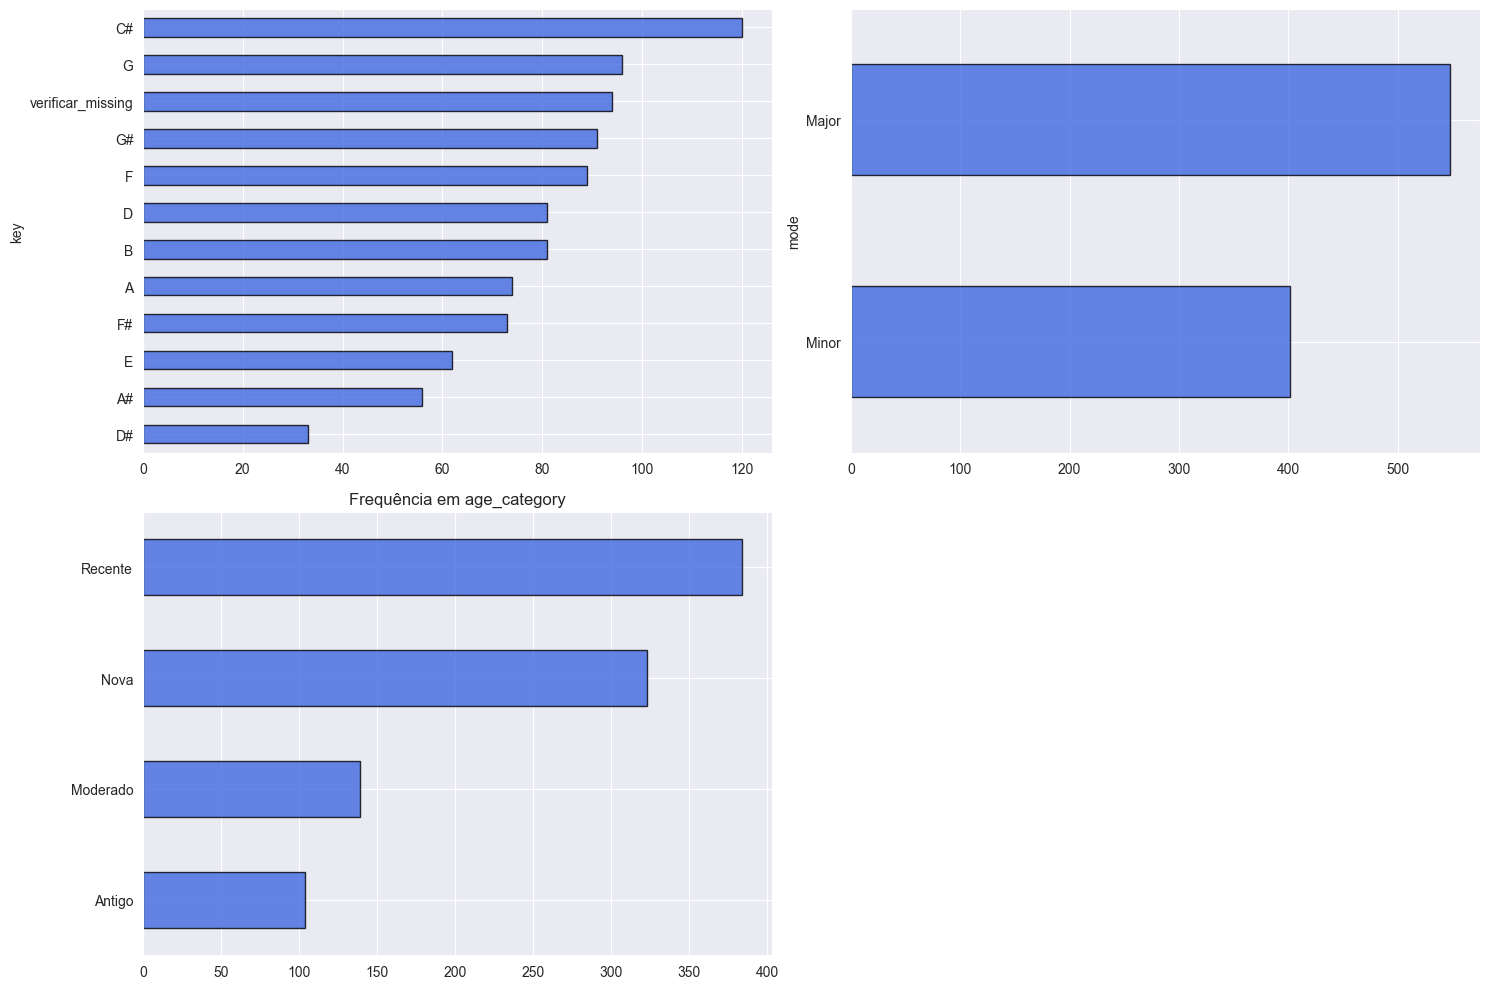

In [133]:
categorical_frequency(df)


### Insights
* Modo (Major vs Minor):
    - Predominância de músicas em Major, indicando tendência a faixas mais comerciais e acessíveis.
* Categoria de idade:
    - Forte concentração em músicas Recentes e Novas, evidenciando viés temporal do dataset.
* Tonalidade (key):
    - Distribuição relativamente equilibrada, sem grande concentração em uma única tonalidade.
* Qualidade dos dados:
    - Presença de valores como "verificar_missing" indica necessidade de revisão no tratamento de dados.

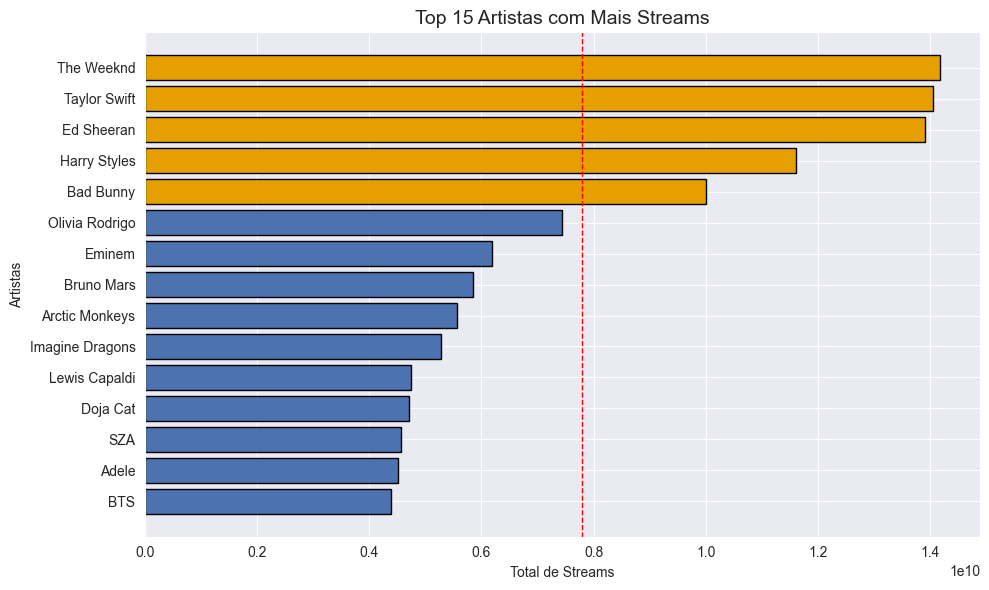

In [134]:
# Agrupando por Artista
top_artistas = (
    df.groupby('artist(s)')['streams']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

media = top_artistas.mean()

colors = ['#E69F00' if v > media else '#4C72B0' for v in top_artistas.values]
# Plot
plt.figure(figsize=(10,6))
plt.barh(
        y=top_artistas.index,
        width=top_artistas.values,
        color=colors,
        edgecolor='black'
    )

# linha da media
plt.axvline(
    media,
    color='red',
    linestyle='--',
    linewidth=1
)

plt.title('Top 15 Artistas com Mais Streams', fontsize=14)
plt.xlabel('Total de Streams')
plt.ylabel('Artistas')

# Inverter o eixo (maior no topo)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


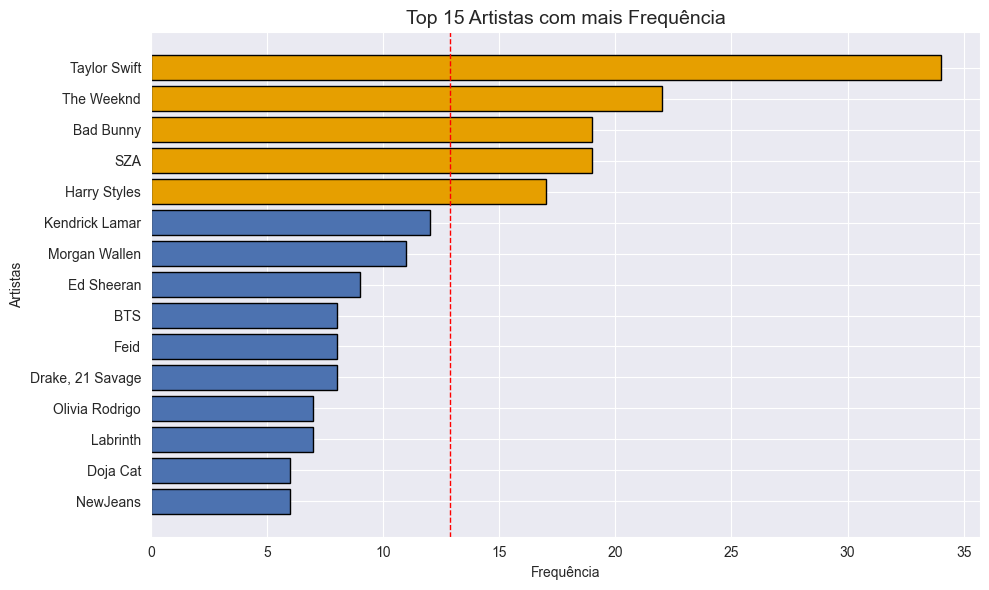

In [135]:
# Agrupando pela frequëncia que o artista aparece no DF
frequencia_artistas = (
    df.groupby('artist(s)')['track_name']
    .count()
    .sort_values(ascending=False)
    .head(15)
)

# media do agrupamento
media_freq = frequencia_artistas.mean()

colors= ['#E69F00' if v > media_freq else '#4C72B0' for v in frequencia_artistas.values]

plt.figure(figsize=(10, 6))
plt.barh(
    y=frequencia_artistas.index,
    width=frequencia_artistas.values,
    color=colors,
    edgecolor='black'
)

# Linha da média
plt.axvline(
    media_freq,
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Média: {media_freq:,.0f}'
)

# Invertendo para o maior ficar no topo
plt.gca().invert_yaxis()

plt.title('Top 15 Artistas com mais Frequência', fontsize=14)
plt.xlabel('Frequência')
plt.ylabel('Artistas')

plt.tight_layout()
plt.show()


#### Análise dos Top 15 Artistas por Streams

#### Visão Geral

O gráfico apresenta os 15 artistas com maior volume total de streams, com destaque para:

- Linha vermelha tracejada representando a média de streams
- Destaque visual para artistas acima da média

---

####  Principais Insights

#### 1. Alta concentração de streams em poucos artistas

- Apenas **5 artistas estão acima da média**
- A maioria dos artistas (10/15) está abaixo da média

Isso indica uma forte concentração de audiência

---

#### 2. Liderança clara de poucos artistas

Os artistas com maior destaque são:

- The Weeknd
- Taylor Swift
- Ed Sheeran
- Harry Styles
- Bad Bunny

Esses artistas estão significativamente acima da média

---

#### 3. Cauda longa de artistas

- A maioria dos artistas apresenta volume semelhante de streams
- Diferença menor entre posições intermediárias

Caracteriza o modelo de "long tail"

---

#### 4. Desigualdade no mercado musical

- Grande diferença entre o topo e o restante
- O topo domina a maior parte do consumo
- Poucos artistas geram a maior parte da receita
- Sucesso altamente concentrado

## 3.3 Análise de Boxplot e Histograma (Variáveis Numéricas)

In [136]:
def boxplot_numerical(pd: pd.DataFrame, graficos_por_linha=3):

    sns.set_style('darkgrid')

    # Seleciona colunas numericas
    cols_num = df.select_dtypes(include=['int64', 'float64']).columns

    if len(cols_num) == 0:
        print('Nenhuma Coluna Numéricas Encontrada')
        return
    
    n_variavels = len(cols_num)

    # Layout
    nlinhas = math.ceil(n_variavels / graficos_por_linha)
    ncolunas = graficos_por_linha

    fig, axs = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=(15, 4*nlinhas))

    # Ajuste dos eixos
    if n_variavels == 1:
        axs = [axs]
    else:
        axs= axs.flatten()

    # Plot
    for i, col in enumerate(cols_num):
        sns.boxplot(x= df[col], ax=axs[i], showfliers=True)

        axs[i].set_title(f'boxplot - {col}')
        axs[i].set_xlabel('')

    # Remove os eixos vazios
    for j in range(i+1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

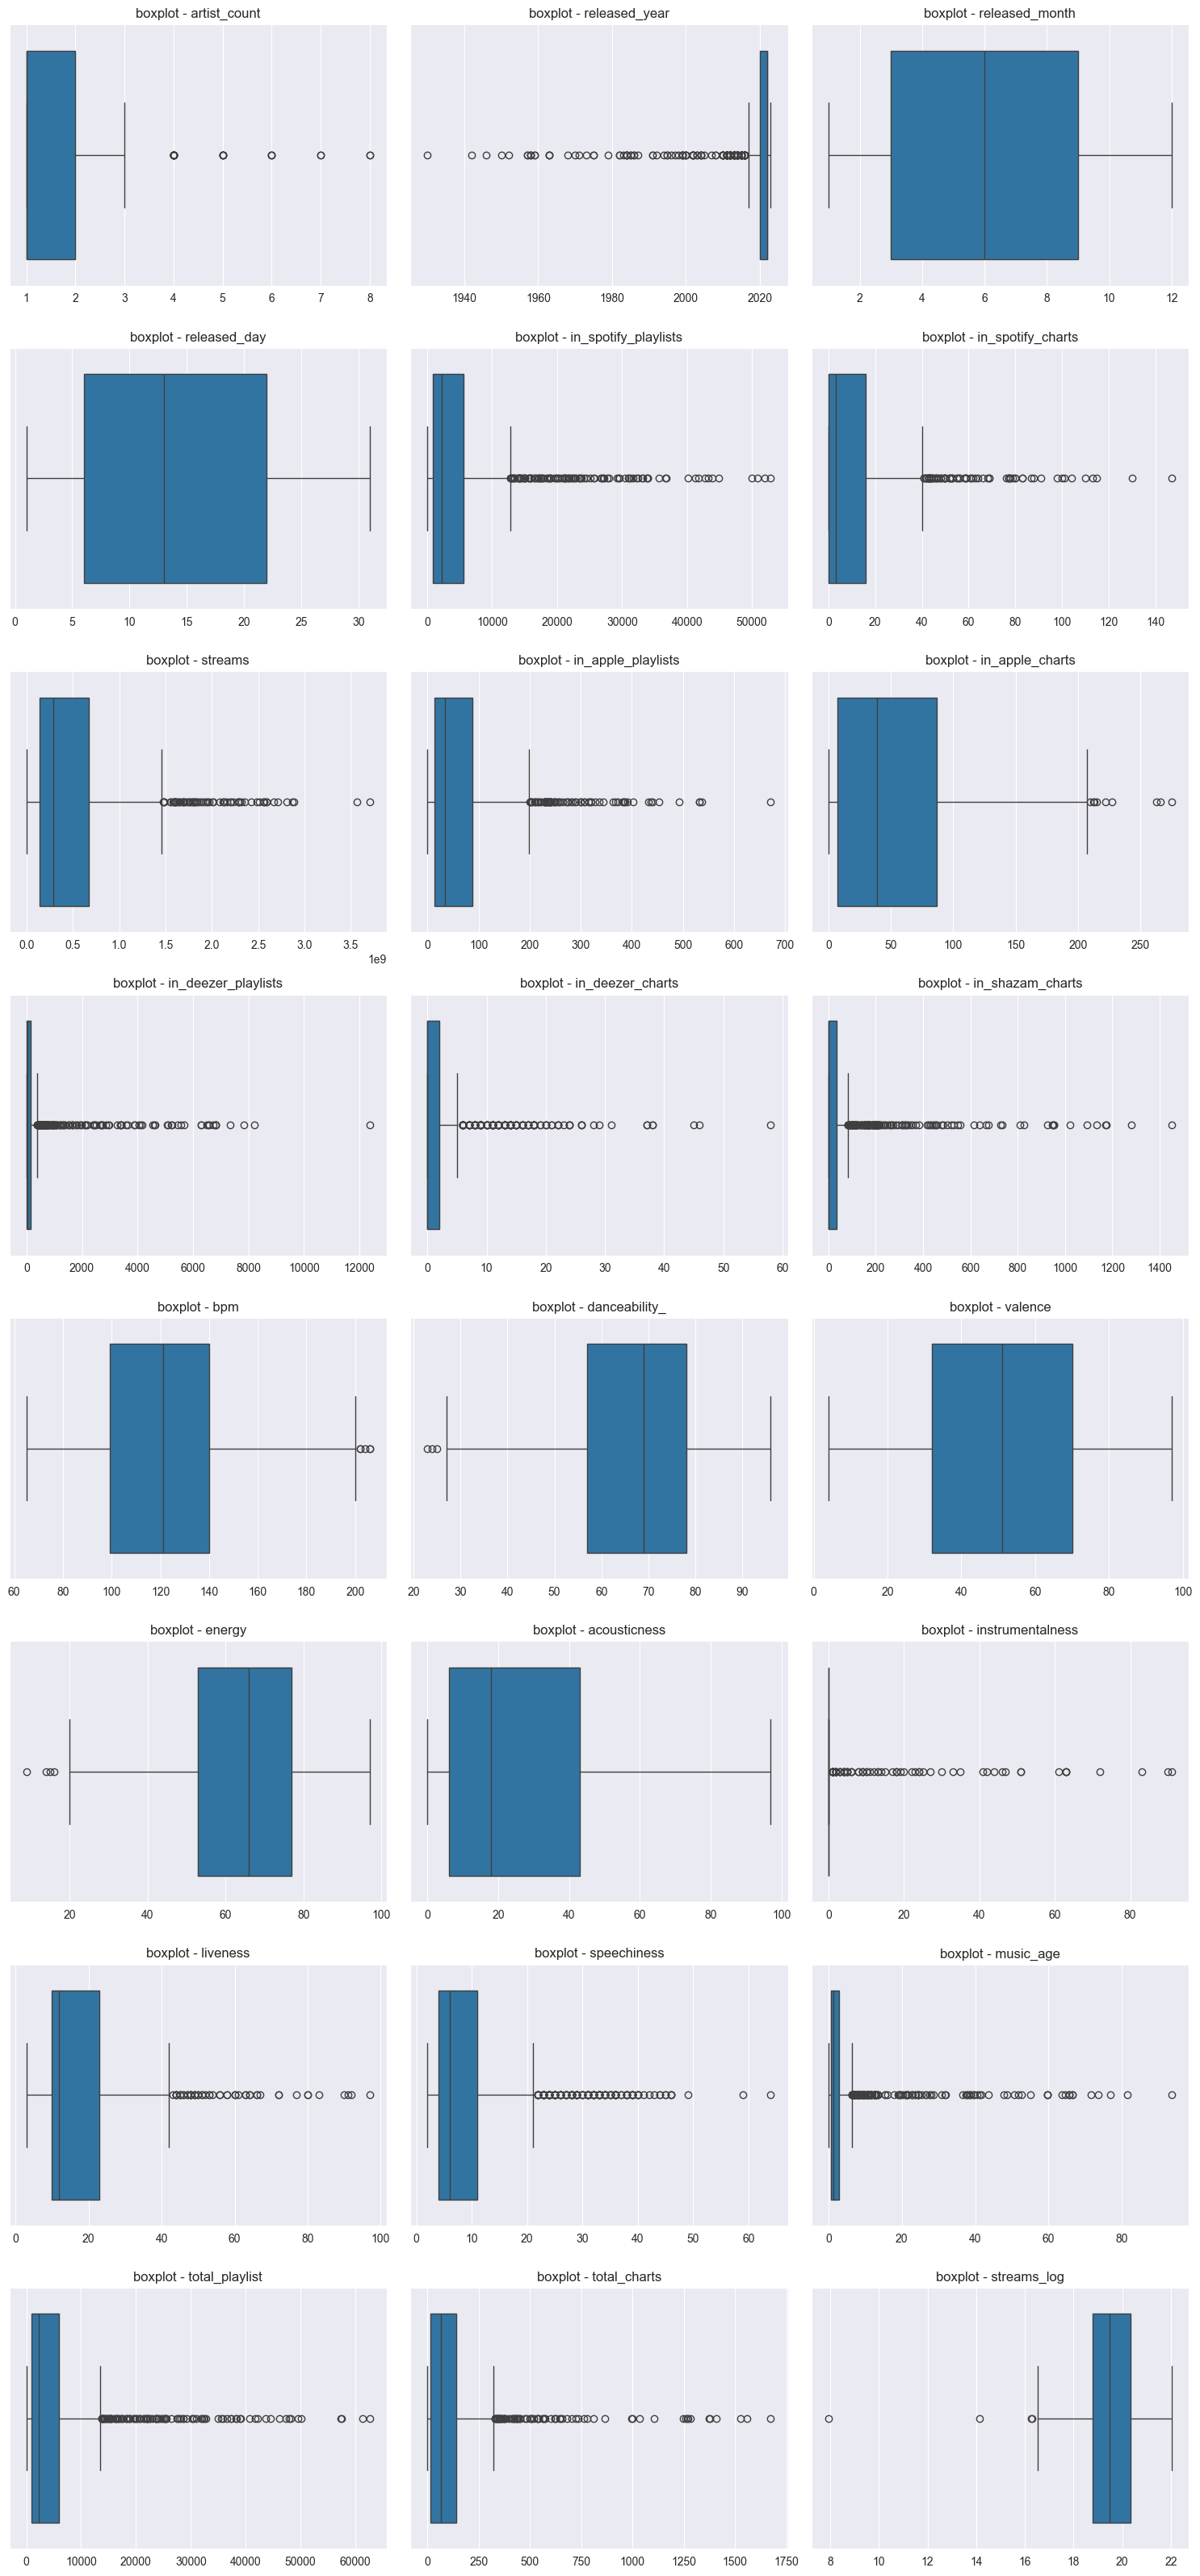

In [137]:
boxplot_numerical(df)

### Principais Insights (Análise de Boxplot)

#### Distribuição de Popularidade
- Variáveis como `streams`, `playlists` e `charts` apresentam:
  - Forte assimetria à direita  
  - Muitos outliers extremos  
- Indica padrão de **cauda longa**, onde poucos hits concentram grande parte da popularidade  

---

#### Exposição em Plataformas
- Variáveis como `in_spotify_playlists`, `in_apple_playlists` e `total_playlist` possuem alta dispersão  
- Sugere que a visibilidade é **altamente desigual entre as músicas**  

---

#### Viés Temporal
- `released_year` e `music_age` mostram concentração em músicas recentes  
- Confirma presença de **recency bias** no dataset  

---

#### Características Musicais
- Variáveis como `bpm`, `danceability`, `valence` e `energy` apresentam distribuição mais estável  
- Indica que atributos musicais são **mais padronizados e menos extremos**  

---

#### Perfil das Músicas
- Baixos valores em:
  - `acousticness`  
  - `instrumentalness`  
  - `liveness`  
  - `speechiness`  
- Indicam predominância de músicas:
  - Produzidas (não acústicas)  
  - Com vocais  
  - Não ao vivo  

---

#### Transformação Logarítmica
- `streams_log` apresenta distribuição mais equilibrada  
- Mais adequada para análises estatísticas e modelagem  

---

### Conclusão

O dataset apresenta forte concentração de popularidade em poucos registros, alta desigualdade de exposição entre músicas e predominância de conteúdos recentes. As variáveis musicais são mais estáveis, enquanto métricas de desempenho são altamente assimétricas, exigindo tratamento adequado para análises mais avançadas.

In [138]:
def histograma_numerical(df:pd.DataFrame, graficos_por_linha=3):

    sns.set_style('darkgrid')

    # Seleciona colunas numericas
    cols_num = df.select_dtypes(include=['int64', 'float64']).columns

    if len(cols_num) == 0:
        print('Nenhuma Coluna Numéricas Encontrada')
        return
    
    n_variavels = len(cols_num)

    # Layout
    nlinhas = math.ceil(n_variavels / graficos_por_linha)
    ncolunas = graficos_por_linha

    fig, axs = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=(15, 4*nlinhas))

    # Ajuste dos eixos
    if n_variavels == 1:
        axs = [axs]
    else:
        axs= axs.flatten()

    # Plot
    for i, col in enumerate(cols_num):
        sns.histplot(x= df[col], ax=axs[i], bins=30, kde=True, edgecolor='black')

        axs[i].set_title(f'Histograma - {col}')
        axs[i].set_xlabel('')
        axs[i].axvline(df[col].mean(), color='red', linestyle='--')

    # Remove os eixos vazios
    for j in range(i+1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

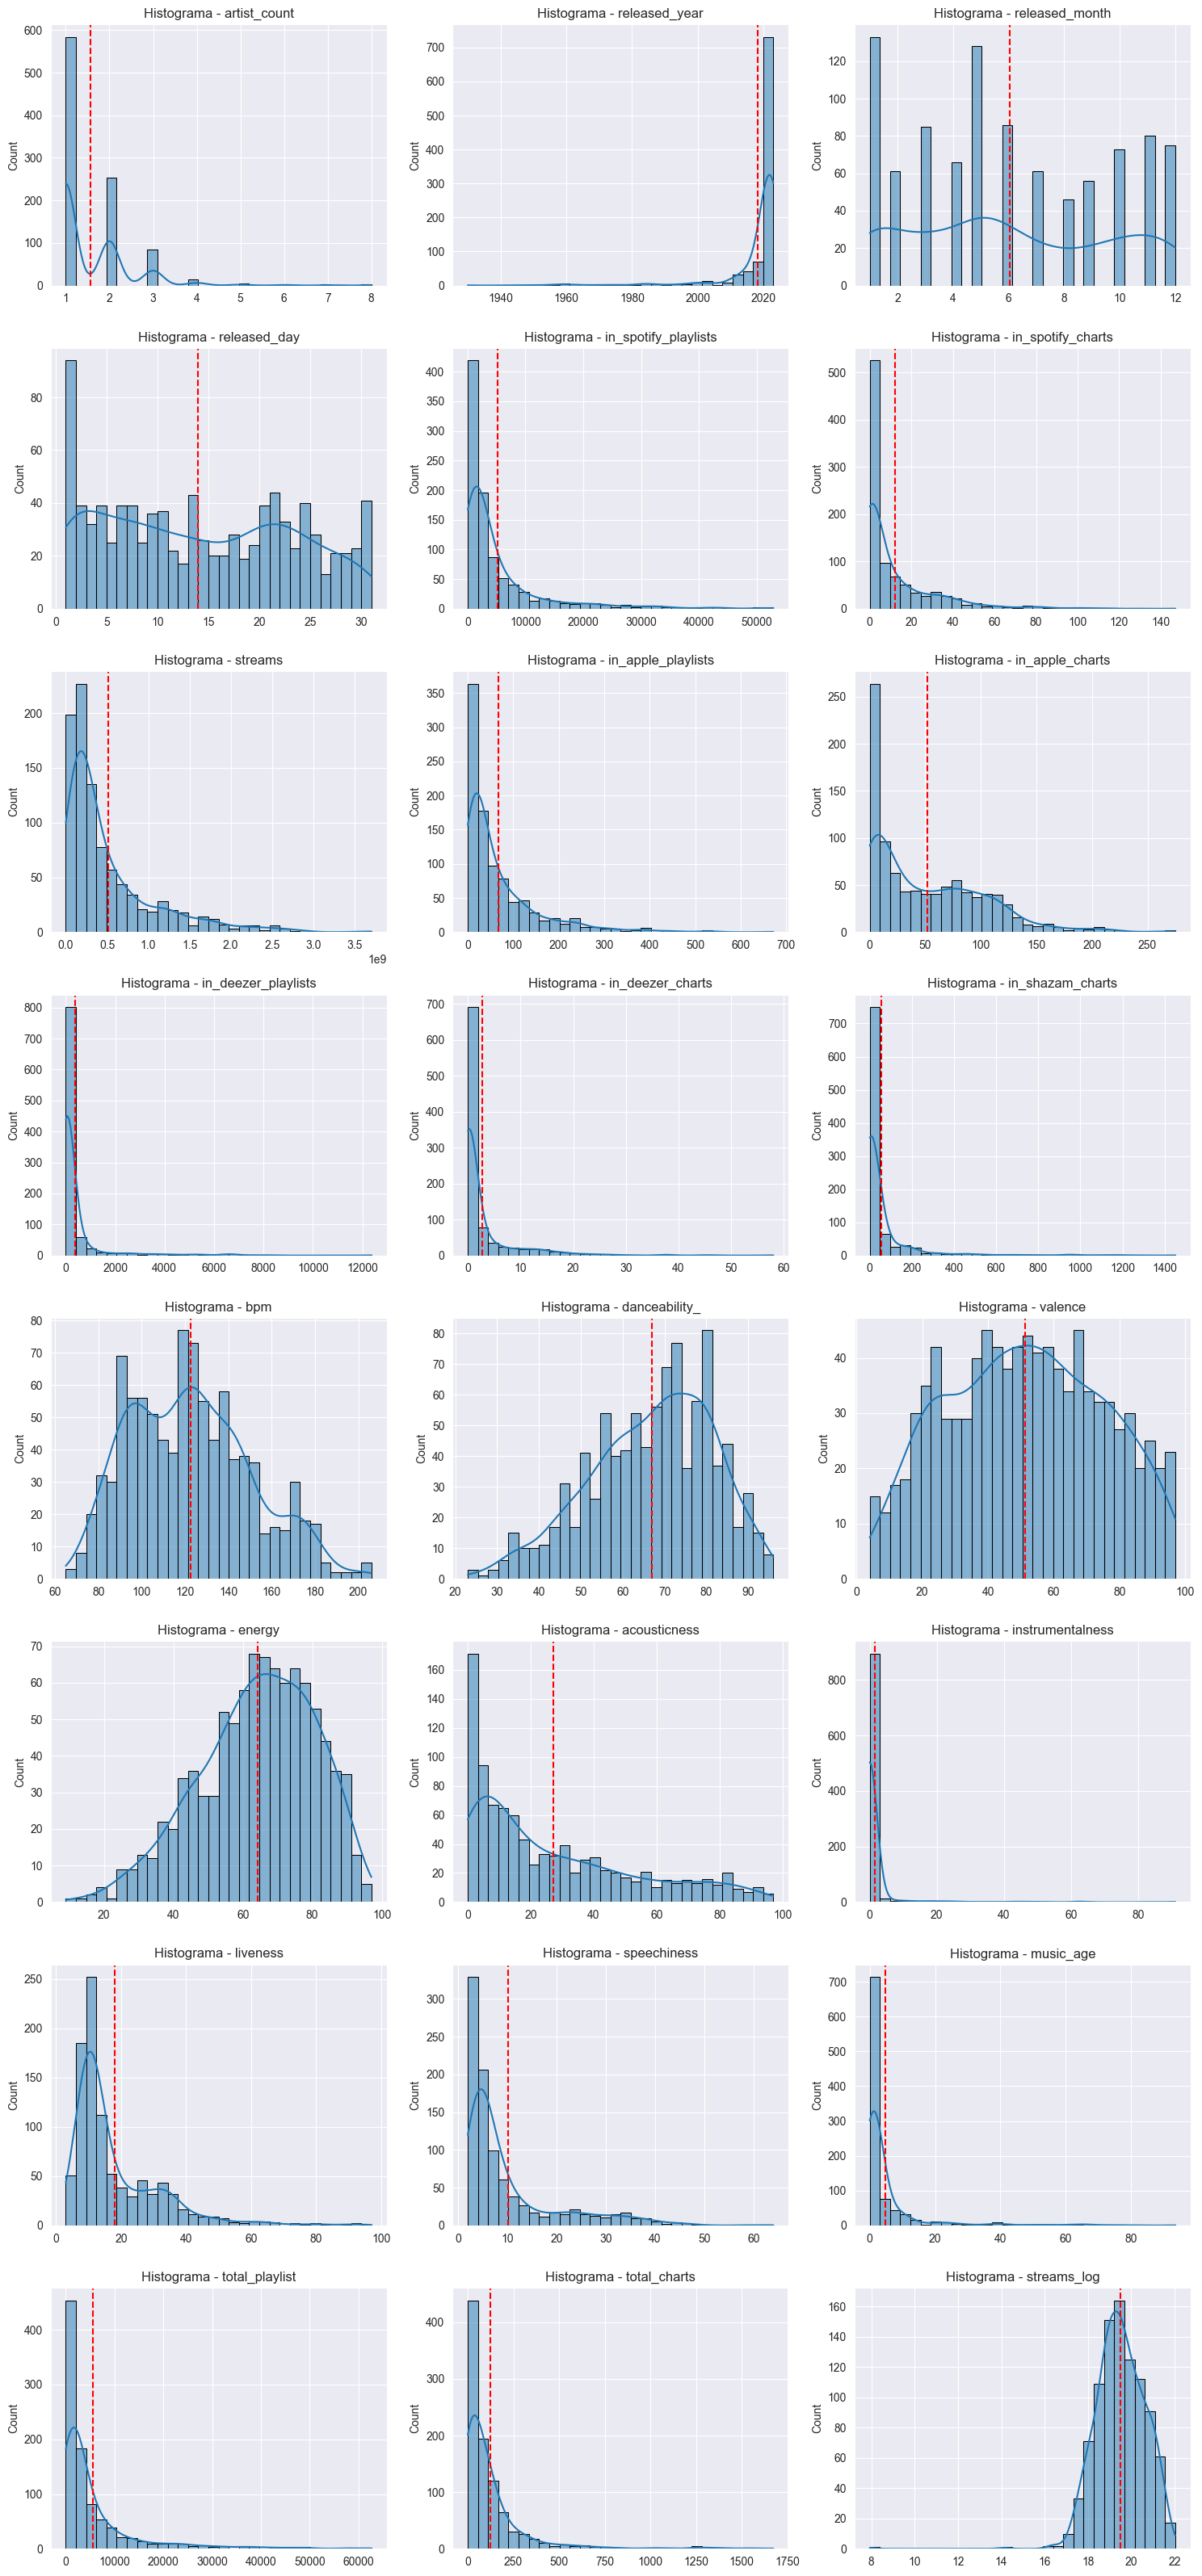

In [139]:
histograma_numerical(df)

#### Análise de Distribuição dos Dados (Histogramas)

#### Principais Observações

- A maioria das variáveis apresenta distribuição assimétrica à direita (cauda longa)
- Poucas músicas concentram grande parte dos streams
- Playlists e charts seguem padrão desigual de distribuição
- Variáveis musicais apresentam distribuição mais equilibrada
- Instrumentalness é altamente concentrado em zero (músicas com vocal predominam)
- A transformação logarítmica normalizou a distribuição de streams

---

#### Insights de Negócio

- O mercado musical é altamente concentrado em poucos sucessos (hit-driven)
- A presença em playlists é um fator crítico de crescimento
- Características musicais não são determinantes para o sucesso
- Músicas com vocal têm maior potencial de alcance
- Estratégias devem priorizar distribuição e visibilidade

---

#### Recomendações

- Investir em estratégias de inclusão em playlists
- Aumentar volume de lançamentos para diluir risco
- Priorizar marketing e distribuição sobre produção
- Explorar músicas recentes com campanhas rápidas
- Utilizar transformação log para modelagem preditiva

## 3.4 Análise de Correlação com `streams`

### 3.4.1 - Selecionado o coeficiente para correlação (Pearson x Spearman)

In [140]:
# Verificar se os dados são normais (teste de shapiro)
stat, p = shapiro(df['streams'])

print(p)

5.576354179049698e-35


p-value = 5.57e-35
- Rejeitamos a hipótese de normalidade (A variável `streams` NÁO segue uma Distribuição Normal)

<Axes: xlabel='streams', ylabel='total_playlist'>

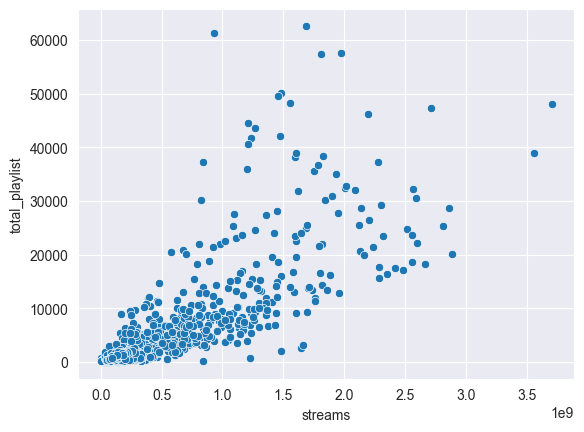

In [141]:
sns.scatterplot(x=df['streams'], y=df['total_playlist'])

In [142]:
# Verificando a correlação Pearson x Spearman
pearson = pearsonr(df['streams'], df['total_playlist'])
spearman = spearmanr(df['streams'], df['total_playlist'])

print('Pearson:', pearson)
print('Spearman:', spearman)


Pearson: PearsonRResult(statistic=np.float64(0.7835752452089713), pvalue=np.float64(3.687068206188301e-198))
Spearman: SignificanceResult(statistic=np.float64(0.8333729898962852), pvalue=np.float64(2.4021177786161306e-246))


In [143]:
# Verificando a correlação de Pearson com o atributo normalizado
pearson_log = pearsonr(df['streams_log'], df['total_playlist'])
print(f'Pearson_log: {pearson_log}')

Pearson_log: PearsonRResult(statistic=np.float64(0.6222462055800747), pvalue=np.float64(6.472530279148169e-103))


#### Interpretação dos p-values

Os p-values obtidos foram:

- Pearson: 3.68e-198  
- Spearman: 2.40e-246  
- Pearson (log): 6.47e-103  

Todos os valores são extremamente baixos (<< 0.05), indicando que as correlações são estatisticamente significativas.

---

#### Interpretação

Os resultados indicam que existe uma relação real entre as variáveis analisadas, independentemente do método utilizado.

No entanto, o p-value não deve ser utilizado como critério para escolha do método de correlação, pois não mede a qualidade do ajuste nem o tipo de relação entre as variáveis.

---

#### Conclusão

A escolha do método de correlação deve ser baseada nas características dos dados e na natureza da relação observada.

Considerando a presença de assimetria, outliers e não linearidade, o **coeficiente de Spearman é o mais adequado para este contexto**.

### 3.4.2 Análise de Correlação

In [144]:
# Função para criar correlação de Spearman

def correlation_with_target(df: pd.DataFrame, target='streams', method='spearman'):

    # Seleciona apenas colunas numéricas
    cols_num = df.select_dtypes(include=['int64', 'float64'])

    # Cálcula correlação
    corr = cols_num.corr(method=method)

    # Correlação com target
    corr_target = corr[target].drop(target).sort_values(ascending=False)

    return pd.DataFrame(corr_target)

In [145]:
# Executando a função
correlation_with_target(df)


,streams
streams_log,1.000000
total_playlist,0.833373
in_spotify_playlists,0.832641
in_deezer_playlists,0.740144
in_apple_playlists,0.673351
music_age,0.668985
in_apple_charts,0.338855
total_charts,0.315727
in_spotify_charts,0.256440
in_deezer_charts,0.229523


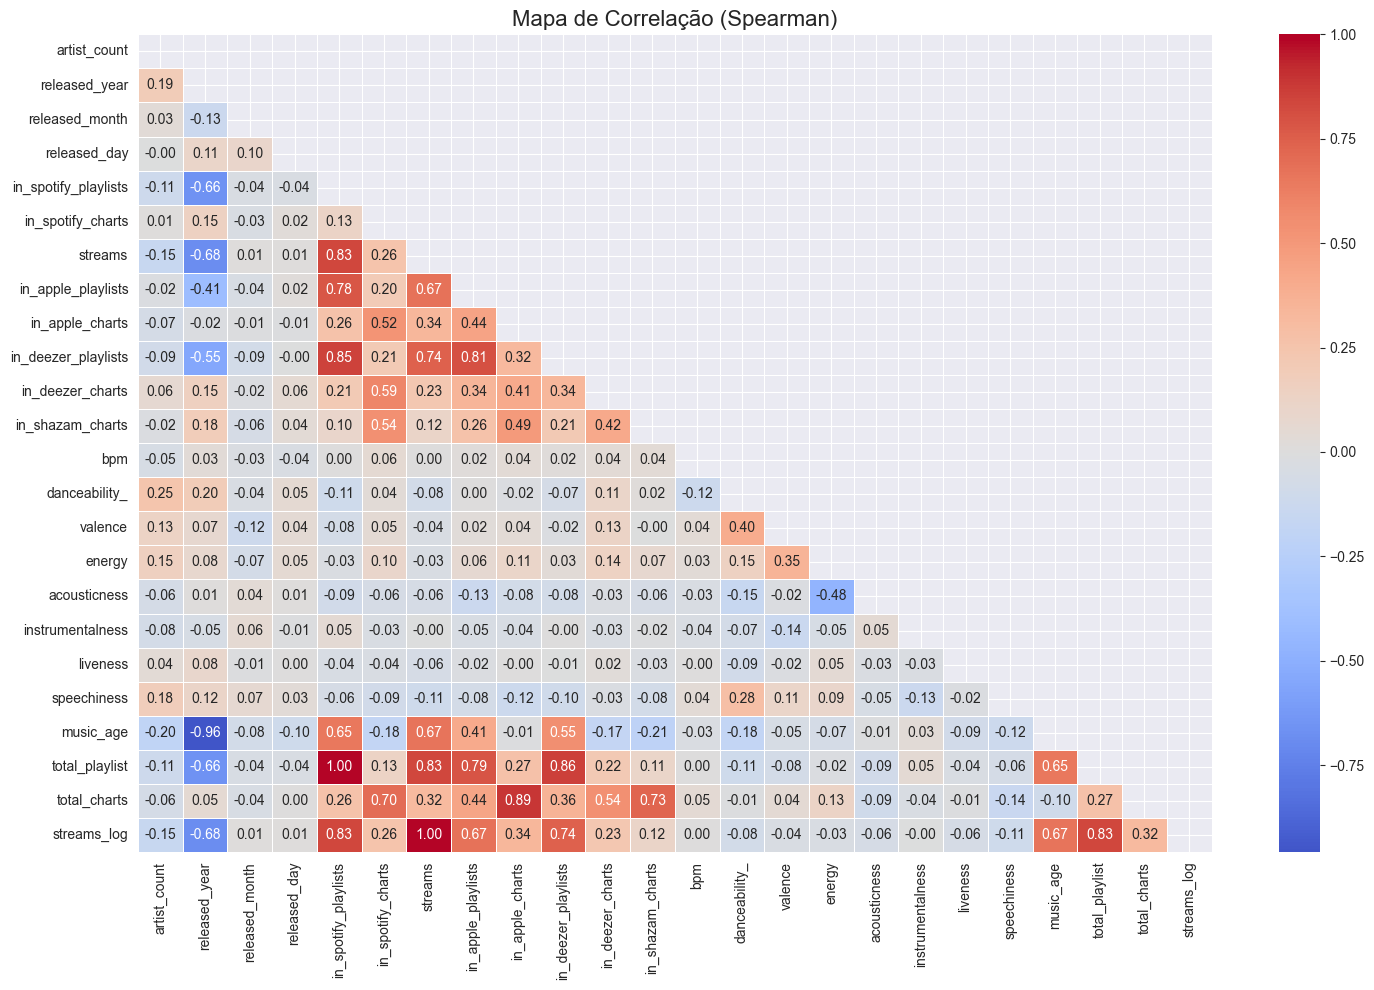

In [146]:
# Gerar um heatmap para visualização melhor a correlação dos atributos
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include=['int64', 'float64']).corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool)) # Não duplicando os atributos para visualização

sns.heatmap(
    corr,
    annot=True, # Anotações dentro do Heatmap
    mask=mask,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Mapa de Correlação (Spearman)', fontsize=16)
plt.tight_layout()
plt.show()

In [147]:
def plot_corr_scatter(df: pd.DataFrame, target='streams', graficos_por_linha=3):
    """
    Função para gerar gráficos de correlação entre variáveis numéricas x variável target
    df: dataframe
    target: variável target da correlação
    graficos_por_linha = gerar quantidade de gráficos por linha (valor padrão = 3)
    """

    # Selecionando colunas numericas
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.to_list()

    # Remove o target da lista
    num_cols.remove(target)

    n_variaveis = len(num_cols)

    # Layout
    nlinhas = math.ceil(n_variaveis / graficos_por_linha)
    ncolunas = graficos_por_linha

    fig, axs = plt.subplots(nrows=nlinhas, ncols=ncolunas, figsize=(15,5*nlinhas))

    # Ajuste dos eixos
    if n_variaveis == 1:
        axs = [axs]
    else:
        axs = axs.flatten()

    # plot
    for i, col in enumerate(num_cols):

        sns.scatterplot(
            x=df[col],
            y=df[target],
            ax=axs[i],
            alpha=0.8
        )

        axs[i].set_title(f'{col} vs {target}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(target)

    # Remove os gráficos vazios
    for j in range(i+1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

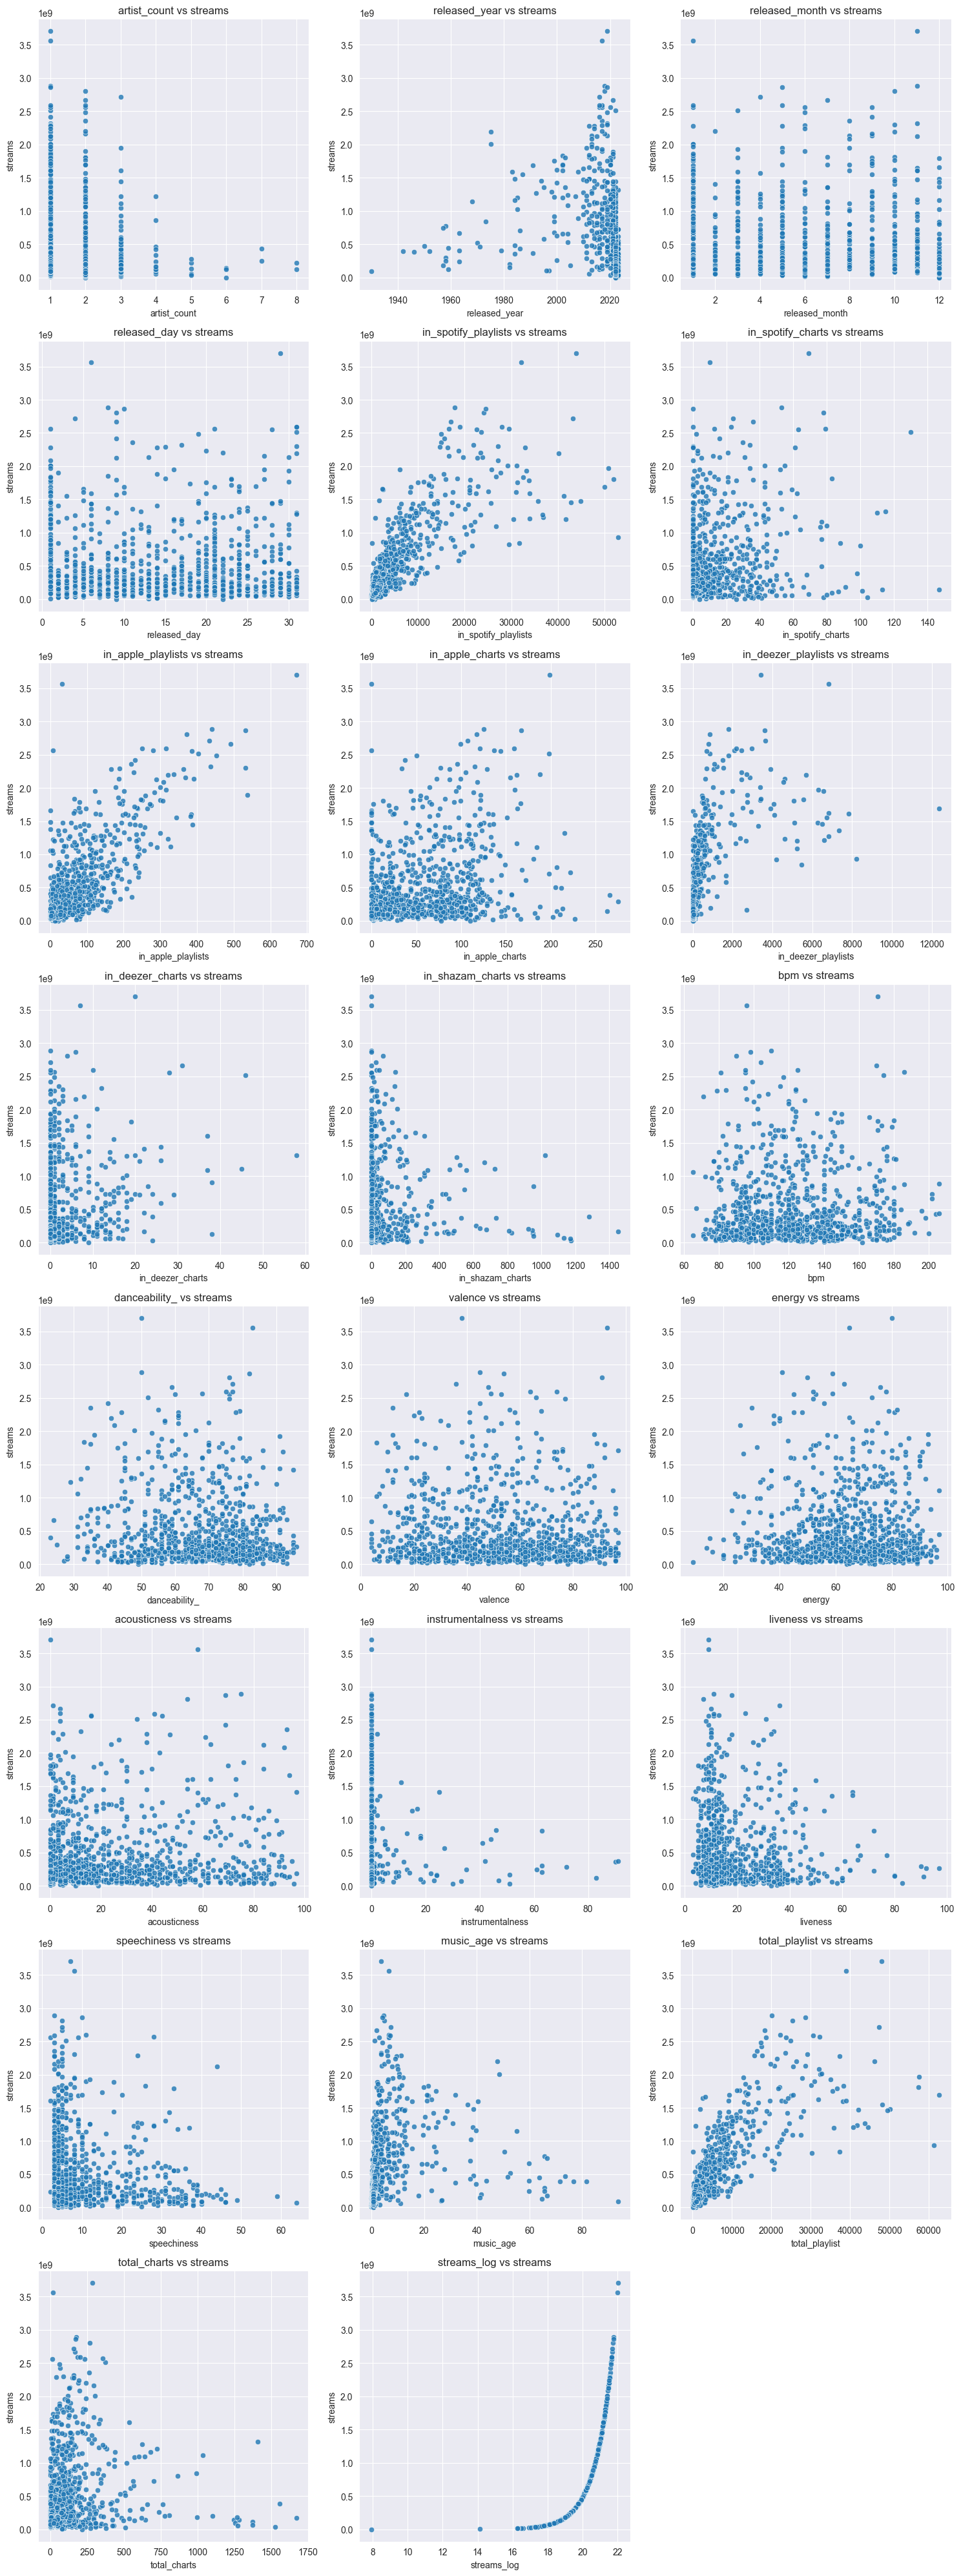

In [148]:
# Executando função para visualização de correlação.
plot_corr_scatter(df)

#### Insights de Negócio – Análise de Correlação

#### Principais Conclusões

- A presença em playlists é o principal fator associado ao aumento de streams
- Variáveis musicais apresentam baixo impacto direto no sucesso
- Charts possuem influência moderada, atuando mais como consequência do sucesso
- O comportamento segue o modelo de cauda longa, com poucos hits concentrando grande parte dos streams

---

#### Recomendações Estratégicas

#### 1. Foco em Playlists
- Priorizar inclusão em playlists relevantes
- Desenvolver parcerias com curadores
- Criar playlists próprias

---

#### 2. Investimento em Distribuição
- Direcionar recursos para marketing e exposição
- Otimizar estratégias de lançamento

---

#### Otimização de Custos

- Reduzir investimento excessivo em produção musical
- Focar em estratégias com maior ROI (playlists e distribuição)

## 3.5 Análise de Pareto (80/20)
Análise dos 80% dos artista que compöe a quantidade de Streams.

In [151]:
# MONTANDO ESTRUTURA DE PARETO

# Agrupamento por Artistas
df_artistas = (
    df.groupby('artist(s)')['streams']
    .sum()  
    .sort_values(ascending=False)
    .reset_index()
)

df_artistas['perc'] = df_artistas['streams'] / df_artistas['streams'].sum()
df_artistas['perc_acumulado'] = df_artistas['perc'].cumsum()

# Identificando o ponto exato dos 80%
pareto_80 = df_artistas[df_artistas['perc_acumulado'] <= 0.805]
rank_80 = len(pareto_80) # O índice representa o Rank

qtd_artistas = df['artist(s)'].nunique()
percent_artistas = round(rank_80 / qtd_artistas, 2) * 100

print(f'Quantidade de artistas que representam os 80% é: {rank_80}')
print(f'Quantidade de artistas no total é de: {qtd_artistas}')
print(f'Representação dos artista que correspondem os 80% é de: {percent_artistas}%')

Quantidade de artistas que representam os 80% é: 221
Quantidade de artistas no total é de: 644
Representação dos artista que correspondem os 80% é de: 34.0%


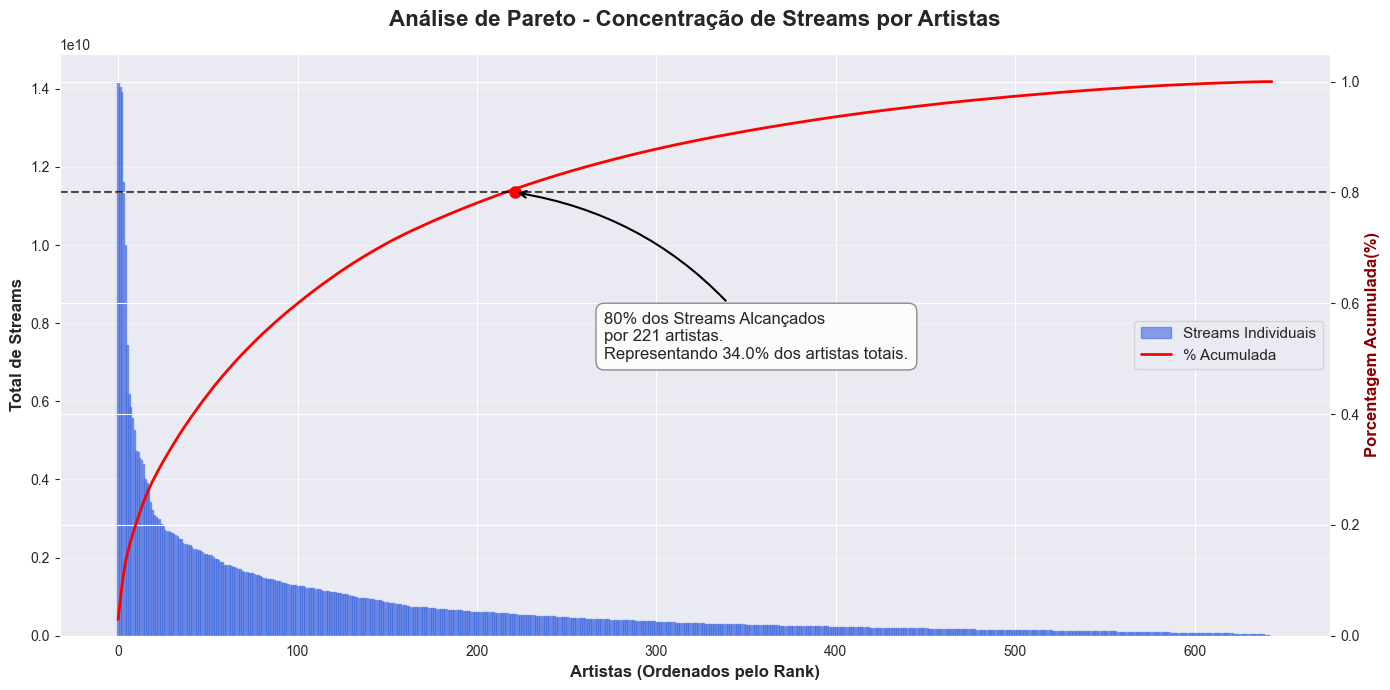

In [ ]:
# GRÁFICO DE PARETO

fig, ax1 = plt.subplots(figsize=(14,7))

# Eixo 1: Barras de Streams
ax1.bar(df_artistas.index, df_artistas['streams'], color='royalblue', alpha=0.6, label='Streams Individuais', edgecolor='royalblue')
ax1.set_xlabel('Artistas (Ordenados pelo Rank)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total de Streams', fontsize=12, fontweight='bold')


# Eixo 2: Linha de porcentagem acumulada
ax2 = ax1.twinx()
ax2.plot(df_artistas.index, df_artistas['perc_acumulado'], color='red', linewidth=2, label='% Acumulada')
ax2.set_ylabel('Porcentagem Acumulada(%)', fontsize=12, fontweight='bold', color='darkred')
ax2.set_ylim(0, 1.05) # Garante que vai até o fim

# Linha horizontal nos 80%
ax2.axhline(0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Anotação do indicador com seta
ax2.annotate(f'80% dos Streams Alcançados\npor {rank_80} artistas.\nRepresentando {percent_artistas}% dos artistas totais.',
             xy=(rank_80, 0.8), # coordenadas da seta
             xytext=(rank_80 + 50, 0.5), # localização do texto
             fontsize=12,
             bbox= dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.9),    # caixa de texto
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3, rad=.2', color='black', lw=1.5) # estilo da seta
             )

# Marcar ponto de interação
ax2.plot(rank_80, 0.8, marker='o', color='red', markersize=8)

plt.title('Análise de Pareto - Concentração de Streams por Artistas', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, axis='y', alpha=0.5)

# Unificar legenda dos dois eixos
lines,labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right', fontsize=11)

plt.tight_layout()
plt.show()

#### Insights Principais

- Ponto de Equilíbrio (80/34): Identificamos que 221 artistas são responsáveis por 80% do volume total de streams.

- Eficiência do Catálogo: Diferente da regra clássica de 80/20 (onde 20% dos itens geram 80% do valor), nossa base apresenta uma concentração de 34%.

- Interpretação: O mercado analisado é menos concentrado que a média. Isso indica que a audiência não está focada apenas em "Superstars", havendo um consumo relevante de artistas de médio porte.

- A "Cauda Longa": Os outros 66% dos artistas dividem entre si apenas os 20% restantes dos streams. Embora representem a maioria em número de pessoas, o impacto financeiro/audiência individual é marginal.

#### Recomendações de Negócio
Como 34% dos artistas compõem a maior parte dos streams, existe uma "classe média" robusta.

- Estratégias não devem focar apenas em superstars
- Investimento em portfólio diversificado é essencial
- Artistas intermediários representam oportunidade de escala

## Recomendações Estratégicas

Com base nas análises realizadas, destacam-se as seguintes ações:

##  1. Foco em distribuição

A forte correlação entre presença em playlists e streams indica que:
- Investimentos em curadoria e distribuição são essenciais
- Estar em playlists relevantes aumenta significativamente o alcance

---

##  2. Estratégia de portfólio

A análise de Pareto mostrou que:
- O sucesso não está concentrado apenas em poucos artistas
- Uma base maior de artistas contribui significativamente

Recomendação:
- Investir em artistas emergentes
- Desenvolver catálogo diversificado

---

##  3. Aproveitamento da cauda longa

- Muitos artistas possuem baixa participação individual
- Mas impacto relevante quando agregados

Recomendação:
- Estratégias segmentadas por nicho
- Explorar públicos específicos

---

##  4. Evitar dependência de hits

- Mercado não é exclusivamente baseado em superstars
- Reduzir risco com diversificação

---

##  Conclusão

O sucesso musical está fortemente ligado à distribuição e presença em plataformas, com um comportamento de consumo mais distribuído do que o esperado. Estratégias eficazes devem equilibrar investimento em grandes artistas e no desenvolvimento de um portfólio amplo.